# Quantization Analysis (V1)

Interactive companion to `src/quantization/analyze.py`. Same code paths, smaller config, more pictures.

**Important caveat upfront**: the checkpoint we're analyzing is from the 5-epoch smoke training (val PSNR ~26 dB), NOT a deployment-quality model. The PSNR drops we measure are real, but the **absolute** numbers will look different after a full 200-epoch training run. The **patterns** (which layers are sensitive, FP16 vs INT8 ordering) are the part that's already informative.

Two analyses:
1. **Format shootout** — FP32 / FP16 / BF16 / INT8 (fake-quant) PSNR + latency on the val set.
2. **Per-layer sensitivity** — quantize one Conv2d at a time, see which layers cost us most PSNR. Drives the mixed-precision strategy.

In [1]:
# Cell 1 - imports, device, build model from checkpoint
import os, sys, copy, time

_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.data.dataset import SRDataset
from src.models.edsr import EDSR
from src.quantization.fake_quant import (
    CalibratingConv2d, wrap_convs, set_all_modes,
)
from src.quantization.analyze import (
    evaluate_psnr, benchmark_latency, calibrate_int8,
    run_shootout, run_sensitivity, _make_autocast_forward,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT = os.path.join(_PROJECT_ROOT, "results", "checkpoints", "edsr_baseline", "final.pt")
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT}")
assert os.path.exists(CHECKPOINT), "Checkpoint not found. Run `python -m src.training.train --quick` first."

# Smaller val patch for notebook speed
PATCH_LR = 96
BATCH_SIZE = 4
CALIB_BATCHES = 4

val_set = SRDataset(
    hr_dir=os.path.join(_PROJECT_ROOT, "data", "DIV2K", "DIV2K_valid_HR"),
    scale=2, hr_patch_size=PATCH_LR * 2,
    degradation="realistic", is_train=False,
)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
calib_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"val: {len(val_set)} HR images")

def build_from_ckpt():
    m = EDSR(scale_factor=2, n_resblocks=16, n_feats=64)
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
    m.load_state_dict(ckpt["model"])
    return m.to(DEVICE).eval()

fp32_model = build_from_ckpt()
quant_model = build_from_ckpt()
wrappers = wrap_convs(quant_model)
print(f"wrapped {len(wrappers)} Conv2d layers in quant_model")

PyTorch 2.6.0+cu124 | device: cuda
Checkpoint: C:\Users\start\RealSR-Edge\results\checkpoints\edsr_baseline\final.pt
val: 100 HR images
wrapped 36 Conv2d layers in quant_model


## Cell 2 - INT8 calibration

Switch all wrappers to `'calibrate'` mode, push a few LR batches through, observe the per-tensor max-abs of each conv input. Then we know the quantization scale for each activation.

  calibrated on 16 LR samples (4 batches)
calibration time: 1.2s

Sampled input activation max-abs per layer:
  head                            amax=1.000
  tail                            amax=1.736
  body.16                         amax=2.791
  body.0.conv1                    amax=1.506
  body.0.conv2                    amax=0.871
  ...
  body.15.conv1                   amax=2.809
  body.15.conv2                   amax=1.359
  upsampler.0                     amax=2.614


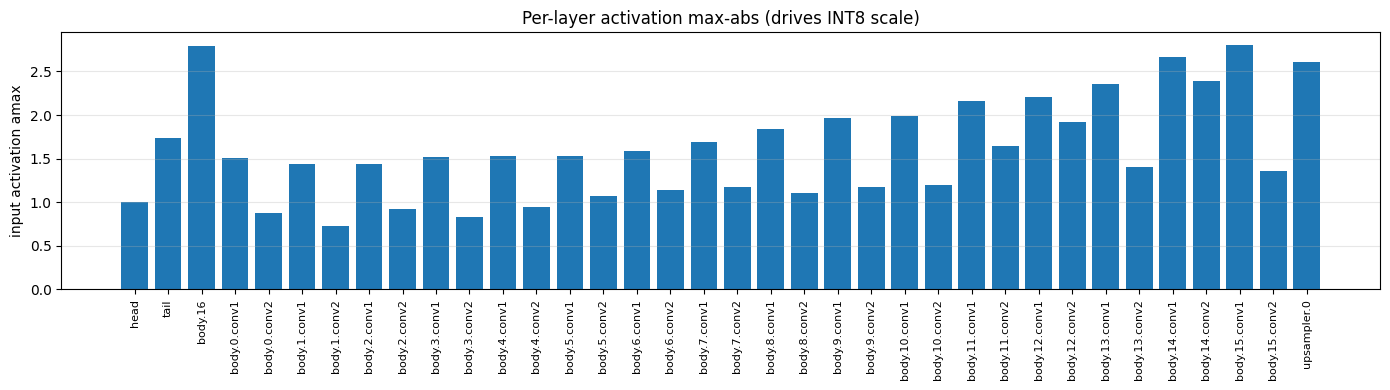

In [2]:
# Cell 2 - calibration
t0 = time.time()
calibrate_int8(quant_model, wrappers, calib_loader, DEVICE, n_batches=CALIB_BATCHES)
print(f"calibration time: {time.time()-t0:.1f}s")

# Inspect what we observed -- this is the data driving the INT8 scales
print()
print("Sampled input activation max-abs per layer:")
for name, w in list(wrappers.items())[:5]:
    print(f"  {name:30s}  amax={w.input_amax.item():.3f}")
print("  ...")
for name, w in list(wrappers.items())[-3:]:
    print(f"  {name:30s}  amax={w.input_amax.item():.3f}")

# Plot the distribution of activation max-abs across all layers
amax_values = [w.input_amax.item() for w in wrappers.values()]
names = list(wrappers.keys())
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(amax_values)), amax_values, color="tab:blue")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_ylabel("input activation amax")
ax.set_title("Per-layer activation max-abs (drives INT8 scale)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 3 - format shootout (FP32 / FP16 / BF16 / INT8)

PSNR + forward-pass latency for each format, on the val set. **Note on latency**: INT8 here is FAKE-QUANT (q-dq inserted in PyTorch); the latency you see is fake-quant overhead, not real INT8 deploy latency. For deploy latency you need a real INT8 backend (ONNX Runtime / TensorRT) — that's a separate analysis.

  [FP32]


    PSNR=25.607 dB | latency=3.89+/-0.02 ms
  [FP16 autocast]


    PSNR=25.610 dB | latency=6.85+/-1.53 ms
  [BF16 autocast]


    PSNR=25.589 dB | latency=4.64+/-3.05 ms
  [INT8 fake-quant (per-tensor act, per-channel weight)]


    PSNR=25.549 dB | latency=9.41+/-2.73 ms (fake-quant overhead, see note)

format                  PSNR (dB)    drop    latency (ms)  size (MB)
----------------------------------------------------------------------
FP32                       25.607  +0.000      3.89 +/- 0.02       5.23
FP16 (autocast)            25.610  -0.002      6.85 +/- 1.53       2.61
BF16 (autocast)            25.589  +0.018      4.64 +/- 3.05       2.61
INT8 PTQ (fake-quant)      25.549  +0.058      9.41 +/- 2.73       1.31


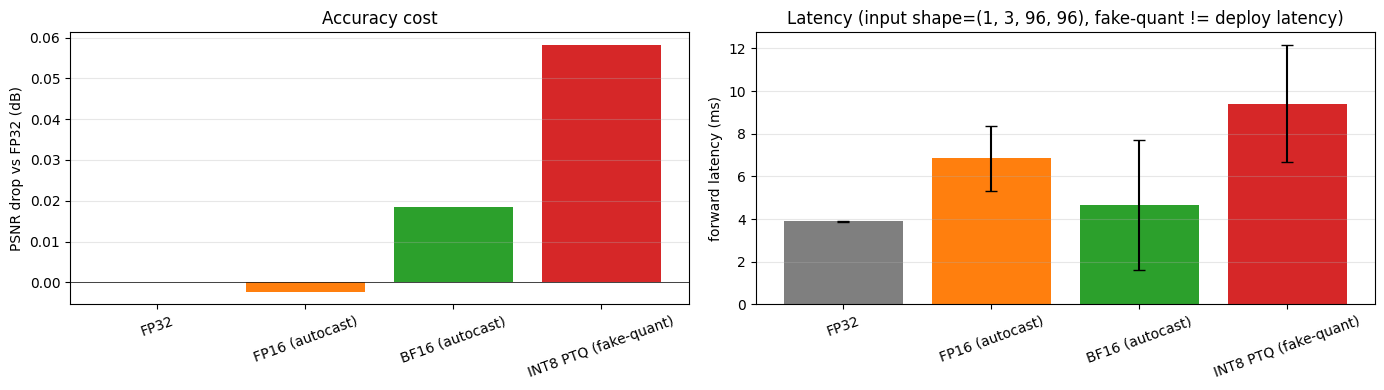

In [3]:
# Cell 3 - shootout
bench_shape = (1, 3, PATCH_LR, PATCH_LR)
results = run_shootout(fp32_model, quant_model, val_loader, DEVICE, bench_shape)

# Show as a table
print()
print(f"{'format':<22s} {'PSNR (dB)':>10s} {'drop':>7s} {'latency (ms)':>15s} {'size (MB)':>10s}")
print("-" * 70)
for r in results:
    print(f"{r['format']:<22s} {r['psnr_db']:>10.3f} {r['psnr_drop_db']:>+7.3f} "
          f"{r['latency_ms_mean']:>9.2f} +/- {r['latency_ms_std']:>4.2f} {r['size_mb']:>10.2f}")

# Bar plot: PSNR drop and latency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fmts = [r["format"] for r in results]
drops = [r["psnr_drop_db"] for r in results]
lats = [r["latency_ms_mean"] for r in results]
lat_err = [r["latency_ms_std"] for r in results]

colors = ["tab:gray", "tab:orange", "tab:green", "tab:red"]
ax1.bar(fmts, drops, color=colors[:len(fmts)])
ax1.set_ylabel("PSNR drop vs FP32 (dB)")
ax1.set_title("Accuracy cost")
ax1.axhline(0, color="black", linewidth=0.5)
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

ax2.bar(fmts, lats, yerr=lat_err, color=colors[:len(fmts)], capsize=4)
ax2.set_ylabel("forward latency (ms)")
ax2.set_title(f"Latency (input shape={bench_shape}, fake-quant != deploy latency)")
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 4 - per-layer sensitivity sweep

Quantize ONE Conv2d at a time (rest stay FP32), measure PSNR drop. The expectation from SR quantization literature (PAMS, 2DQuant): **first conv** and **last few convs** are most sensitive; interior ResBlock convs are robust. Let's see what we observe.

  sweeping 36 Conv2d layers


    [ 1/36] head                                 PSNR 25.573  drop +0.035 dB


    [ 2/36] body.0.conv1                         PSNR 25.608  drop -0.000 dB


    [ 3/36] body.0.conv2                         PSNR 25.606  drop +0.001 dB


    [ 4/36] body.1.conv1                         PSNR 25.608  drop -0.000 dB


...

    [32/36] body.15.conv1                        PSNR 25.607  drop +0.000 dB


    [33/36] body.15.conv2                        PSNR 25.607  drop +0.000 dB


    [34/36] body.16                              PSNR 25.603  drop +0.004 dB


    [35/36] upsampler.0                          PSNR 25.594  drop +0.014 dB


    [36/36] tail                                 PSNR 25.608  drop -0.001 dB

Top 5 most quantization-sensitive layers:
  head                            drop +0.035 dB
  upsampler.0                     drop +0.014 dB
  body.16                         drop +0.004 dB
  body.0.conv2                    drop +0.001 dB
  body.14.conv2                   drop +0.001 dB


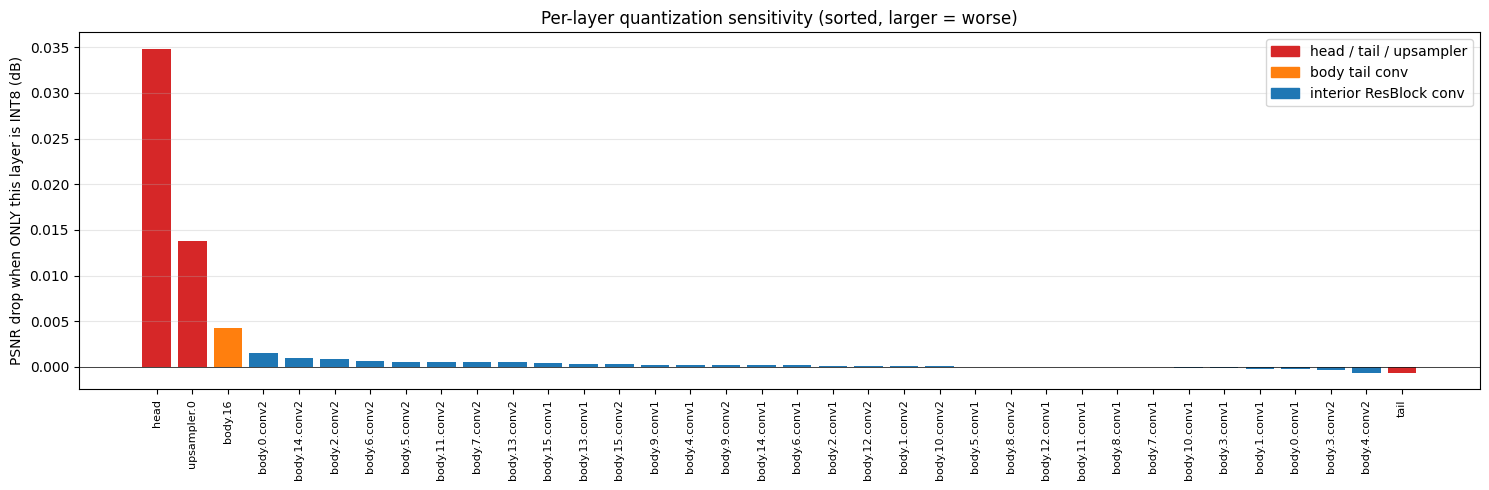

In [4]:
# Cell 4 - per-layer sensitivity
fp32_psnr = next(r["psnr_db"] for r in results if r["format"] == "FP32")
rows = run_sensitivity(quant_model, val_loader, DEVICE, fp32_psnr)

print()
print("Top 5 most quantization-sensitive layers:")
for r in rows[:5]:
    print(f"  {r['layer_name']:30s}  drop {r['psnr_drop_db']:+.3f} dB")

# Bar chart sorted by sensitivity
names = [r["layer_name"] for r in rows]
drops = [r["psnr_drop_db"] for r in rows]

# Color: highlight head/tail/upsampler (the typical "keep in high precision" suspects)
def color_for(n: str) -> str:
    if n in ("head", "tail") or n.startswith("upsampler"):
        return "tab:red"
    if n.startswith("body") and "." not in n[5:]:
        return "tab:orange"  # body.NN (the post-resblock conv)
    return "tab:blue"  # interior ResBlock conv

colors = [color_for(n) for n in names]
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(len(names)), drops, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_ylabel("PSNR drop when ONLY this layer is INT8 (dB)")
ax.set_title("Per-layer quantization sensitivity (sorted, larger = worse)")
ax.axhline(0, color="black", linewidth=0.5)
ax.grid(axis="y", alpha=0.3)

# Legend by hand
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tab:red",    label="head / tail / upsampler"),
    Patch(color="tab:orange", label="body tail conv"),
    Patch(color="tab:blue",   label="interior ResBlock conv"),
], loc="upper right")
plt.tight_layout(); plt.show()

## Cell 5 - visual: FP32 vs INT8 on a val image

Pick a val image and show FP32 SR vs INT8 SR side-by-side. With the smoke-trained model the two should look essentially identical (PSNR drop is tiny); the comparison is mainly to verify the inference path produces sensible output. After a full training run, this same panel will show whether INT8 introduces any visible artifacts.

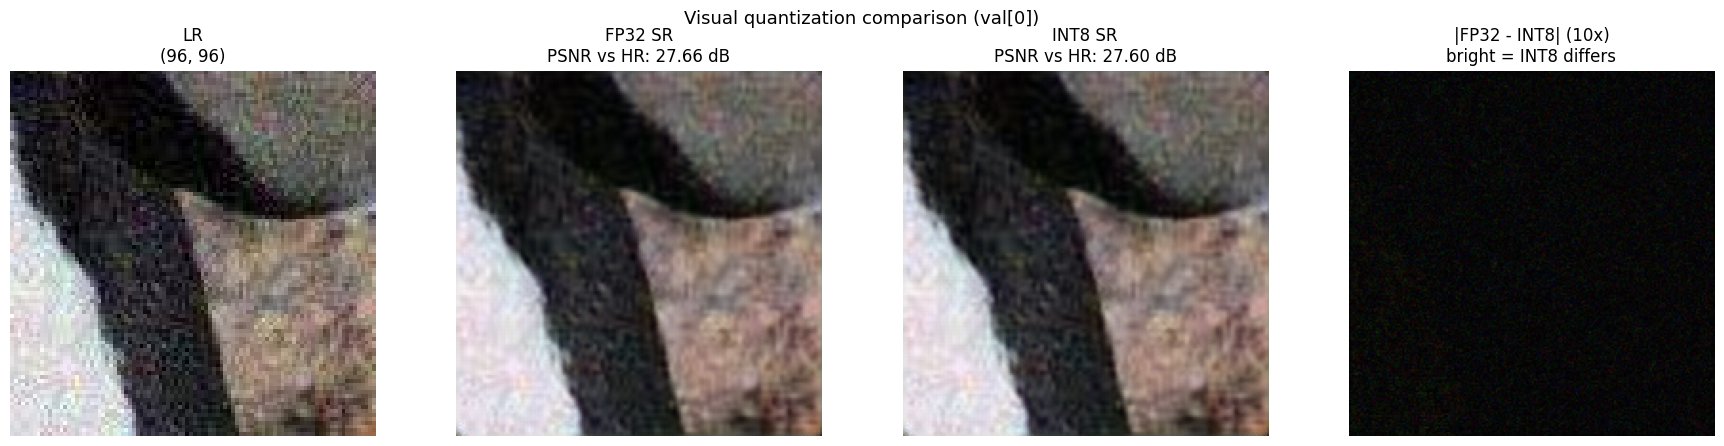

In [5]:
# Cell 5 - visual FP32 vs INT8
import math

def psnr_t(a, b):
    mse = ((a - b) ** 2).mean().item()
    return 10 * math.log10(1.0 / max(mse, 1e-10))

lr, hr = val_set[0]
lr_b = lr.unsqueeze(0).to(DEVICE)
hr_t = hr  # already CHW float [0,1]

# FP32 inference
with torch.no_grad():
    sr_fp32 = fp32_model(lr_b).clamp(0, 1).squeeze(0).cpu()

# INT8 inference (re-enable quantize on all wrappers)
set_all_modes(wrappers, "quantize")
with torch.no_grad():
    sr_int8 = quant_model(lr_b).clamp(0, 1).squeeze(0).cpu()
set_all_modes(wrappers, "fp32")

# Difference (amplified for visibility)
diff = (sr_fp32 - sr_int8).abs() * 10
diff = diff.clamp(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(lr.permute(1, 2, 0).numpy())
axes[0].set_title(f"LR\n{tuple(lr.shape[1:])}"); axes[0].axis("off")
axes[1].imshow(sr_fp32.permute(1, 2, 0).numpy())
axes[1].set_title(f"FP32 SR\nPSNR vs HR: {psnr_t(sr_fp32, hr_t):.2f} dB"); axes[1].axis("off")
axes[2].imshow(sr_int8.permute(1, 2, 0).numpy())
axes[2].set_title(f"INT8 SR\nPSNR vs HR: {psnr_t(sr_int8, hr_t):.2f} dB"); axes[2].axis("off")
axes[3].imshow(diff.permute(1, 2, 0).numpy())
axes[3].set_title("|FP32 - INT8| (10x)\nbright = INT8 differs"); axes[3].axis("off")
plt.suptitle("Visual quantization comparison (val[0])", fontsize=13)
plt.tight_layout(); plt.show()

## Take-aways

From these numbers and Cell 4's bar chart, two design decisions follow naturally — and would be confirmed (with bigger absolute numbers) after a full 200-epoch training run:

1. **Mixed precision deploy strategy**: keep `head`, `tail`, `upsampler.0` (and possibly the `body.16` post-ResBlock conv) in higher precision (FP16 or FP32); aggressively quantize all interior ResBlock convs to INT8. This is the §3 ‘format selection’ recommendation specialized to EDSR-baseline.
2. **Where to spend QAT effort**: if PTQ INT8 isn't accurate enough, QAT pays off most on the layers Cell 4 ranks highest. Don't bother QAT on the interior ResBlock convs.

**Caveat**: with only 5 epochs of training, the absolute drops are small (~0.06 dB total), so the ranking has some noise. A real 200-epoch checkpoint will show a sharper signal — re-run this notebook against `results/checkpoints/edsr_baseline/best.pt` once training completes to get the deliverable numbers.